# Modele prognozowania sprzedaży

### Importy i ładowanie danych

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
import lightgbm as lgb
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import plotly.graph_objects as go
import optuna
from ipywidgets import interact, widgets


def safe_r2(y_true, y_pred, min_std=1.0):
    y_arr = np.asarray(y_true)
    if y_arr.std() < min_std:
        return np.nan
    return r2_score(y_arr, np.asarray(y_pred))


# Connect to the database
db_path = 'ecommerce.db'
conn = sqlite3.connect(db_path)

# Load the data
query = "SELECT * FROM sales_aggregated"
df = pd.read_sql(query, conn)

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

df.head()

2026-04-10 22:12:26.374043: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 22:12:26.406556: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-10 22:12:26.406579: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-10 22:12:26.408476: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-10 22:12:26.416575: I tensorflow/core/platform/cpu_feature_guar

,product_id,date,sales,revenue,price,stock
0,P0001,2017-01-02,6.0,31.79,6.25,195.0
1,P0001,2017-01-03,1.0,5.30,6.25,194.0
2,P0001,2017-01-04,2.0,10.60,6.25,192.0
3,P0001,2017-01-05,1.0,5.30,6.25,191.0
4,P0001,2017-01-06,3.0,15.90,6.25,188.0


### Eksploracja danych

In [2]:
# Strict product eligibility for modeling
STRICT_MIN_DAYS = 180
STRICT_MIN_STD = 3.0
STRICT_MAX_ZERO_SHARE = 0.90
STRICT_MIN_TEST_STD = 1.0  # additional guard to avoid low-variance test targets

product_stats = (
    df.groupby('product_id')['sales']
      .agg(n_days='size', std='std', mean='mean')
      .reset_index()
)
product_stats['std'] = product_stats['std'].fillna(0.0)

product_zero_share = (
    df.assign(is_zero=(df['sales'] <= 0).astype(int))
      .groupby('product_id')['is_zero']
      .mean()
      .reset_index(name='zero_share')
)
product_stats = product_stats.merge(product_zero_share, on='product_id', how='left')

strict_products = product_stats.loc[
    (product_stats['n_days'] > STRICT_MIN_DAYS)
    & (product_stats['std'] >= STRICT_MIN_STD)
    & (product_stats['zero_share'] <= STRICT_MAX_ZERO_SHARE),
    'product_id'
]

# Identify top products from strict-only pool
top_products = (
    df[df['product_id'].isin(strict_products)]
      .groupby('product_id')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
)

# Filter the dataframe
df_top5 = df[df['product_id'].isin(top_products)].copy()

print("Top 5 STRICT Products by Sales:")
print(top_products)
print(f"Strict pool size: {len(strict_products)}")
df_top5.head()

Top 5 STRICT Products by Sales:
Index(['P0103', 'P0438', 'P0364', 'P0051', 'P0388'], dtype='object', name='product_id')
Strict pool size: 303


,product_id,date,sales,revenue,price,stock
27807,P0051,2017-01-02,349.0,226.23,0.7,6972.0
27808,P0051,2017-01-03,305.0,197.71,0.7,6734.0
27809,P0051,2017-01-04,332.0,215.24,0.7,6526.0
27810,P0051,2017-01-05,246.0,159.46,0.7,7212.0
27811,P0051,2017-01-06,429.0,278.04,0.7,7231.0


### Top 5 produktów według sprzedaży

In [3]:
def create_features(df):
    # Always sort first so lag/rolling are truly chronological per product
    df = df.sort_values(by=['product_id', 'date']).copy()

    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year

    # Lag features
    lags = [1, 7, 14, 30]
    for lag in lags:
        df[f'sales_lag_{lag}'] = df.groupby('product_id')['sales'].shift(lag)
        df[f'revenue_lag_{lag}'] = df.groupby('product_id')['revenue'].shift(lag)

    # Rolling statistics computed independently within each product
    rolling_windows = [7, 14]
    for window in rolling_windows:
        df[f'sales_rolling_mean_{window}'] = (
            df.groupby('product_id')['sales']
              .transform(lambda s: s.shift(1).rolling(window).mean())
        )
        df[f'sales_rolling_std_{window}'] = (
            df.groupby('product_id')['sales']
              .transform(lambda s: s.shift(1).rolling(window).std())
        )

    # Use stock only for stockout context; do not use current sales to define this feature
    df['is_out_of_stock'] = (df['stock'] <= 0).astype(int)

    # Avoid leakage from backward filling; drop rows without enough history
    required_cols = [
        'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30',
        'revenue_lag_1', 'revenue_lag_7', 'revenue_lag_14', 'revenue_lag_30',
        'sales_rolling_mean_7', 'sales_rolling_std_7',
        'sales_rolling_mean_14', 'sales_rolling_std_14'
    ]
    df = df.dropna(subset=required_cols).reset_index(drop=True)

    return df

df_featured = create_features(df_top5)
df_featured.head()

,product_id,date,sales,revenue,price,stock,day,dayofweek,month,year,...,revenue_lag_7,sales_lag_14,revenue_lag_14,sales_lag_30,revenue_lag_30,sales_rolling_mean_7,sales_rolling_std_7,sales_rolling_mean_14,sales_rolling_std_14,is_out_of_stock
0,P0051,2017-02-01,375.0,243.10,0.7,7046.0,1,2,2,2017,...,223.67,356.0,230.82,349.0,226.23,398.571429,51.201748,397.428571,48.058801,0
1,P0051,2017-02-02,355.0,230.11,0.7,7298.0,2,3,2,2017,...,235.32,327.0,211.97,305.0,197.71,402.857143,47.058221,398.785714,47.056723,0
2,P0051,2017-02-03,359.0,232.70,0.7,7089.0,3,4,2,2017,...,223.00,404.0,261.86,332.0,215.24,401.714286,48.269087,400.785714,44.284358,0
3,P0051,2017-02-04,374.0,242.41,0.7,6908.0,4,5,2,2017,...,281.34,434.0,281.34,246.0,159.46,403.857143,45.535439,397.571429,45.645312,0
4,P0051,2017-02-05,419.0,271.58,0.7,6649.0,5,6,2,2017,...,283.27,468.0,303.35,429.0,278.04,395.285714,44.552270,393.285714,44.770231,0


### Brakujące wartości

In [4]:
def split_data(df, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

    data_splits = {}
    for product in df['product_id'].unique():
        product_df = (
            df[df['product_id'] == product]
            .sort_values('date')
            .reset_index(drop=True)
        )

        n = len(product_df)
        train_end = int(n * train_ratio)
        val_end = train_end + int(n * val_ratio)

        train_df = product_df.iloc[:train_end].copy()
        val_df = product_df.iloc[train_end:val_end].copy()
        test_df = product_df.iloc[val_end:].copy()

        data_splits[product] = (train_df, val_df, test_df)

    return data_splits


def iqr_outlier_caps(series, iqr_mult=3.0):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = max(0.0, float(q1 - iqr_mult * iqr))
    upper = float(q3 + iqr_mult * iqr)
    return lower, max(upper, lower + 1e-9)


data_splits_raw = split_data(df_featured)

# Extra strict guard: keep only products with non-trivial variance in test target
excluded_low_variance = []
data_splits = {}
for product, (train_df, val_df, test_df) in data_splits_raw.items():
    test_std = float(test_df['sales'].std()) if len(test_df) > 1 else 0.0
    if np.isfinite(test_std) and test_std >= STRICT_MIN_TEST_STD:
        data_splits[product] = (train_df, val_df, test_df)
    else:
        excluded_low_variance.append((product, test_std))

# Keep top_products aligned with filtered splits
top_products = pd.Index([p for p in top_products if p in data_splits])

# Build train-based outlier caps per product to reduce target sensitivity
outlier_caps = {}
for product, (train_df, _, _) in data_splits.items():
    outlier_caps[product] = iqr_outlier_caps(train_df['sales'], iqr_mult=3.0)

# Example for one product
product_example = list(top_products)[0]
train_df, val_df, test_df = data_splits[product_example]
print(f"Product: {product_example}")
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Date range train: {train_df['date'].min()} -> {train_df['date'].max()}")
print(f"Date range val:   {val_df['date'].min()} -> {val_df['date'].max()}")
print(f"Date range test:  {test_df['date'].min()} -> {test_df['date'].max()}")
print(f"Final strict products used in simulation: {list(top_products)}")
print(f"Excluded low-variance products: {excluded_low_variance}")
print(f"Outlier cap for example product (lower, upper): {outlier_caps[product_example]}")

Product: P0103
Train shape: (743, 23)
Validation shape: (159, 23)
Test shape: (160, 23)
Date range train: 2017-02-01 00:00:00 -> 2019-02-13 00:00:00
Date range val:   2019-02-14 00:00:00 -> 2019-07-22 00:00:00
Date range test:  2019-07-23 00:00:00 -> 2019-12-29 00:00:00
Final strict products used in simulation: ['P0103', 'P0364', 'P0051', 'P0388']
Excluded low-variance products: [('P0438', 0.27901971993211655)]
Outlier cap for example product (lower, upper): (0.0, 1784.5)


## 4.1 Data Distribution Verification

Sprawdzenie zgodności rozkładów sprzedaży między zbiorami train/validation/test dla przykładowego produktu po podziale chronologicznym.

DATA DISTRIBUTION VERIFICATION


/tmp/ipykernel_25302/3590048767.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(bp_data, labels=['Train', 'Validation', 'Test'], patch_artist=True)


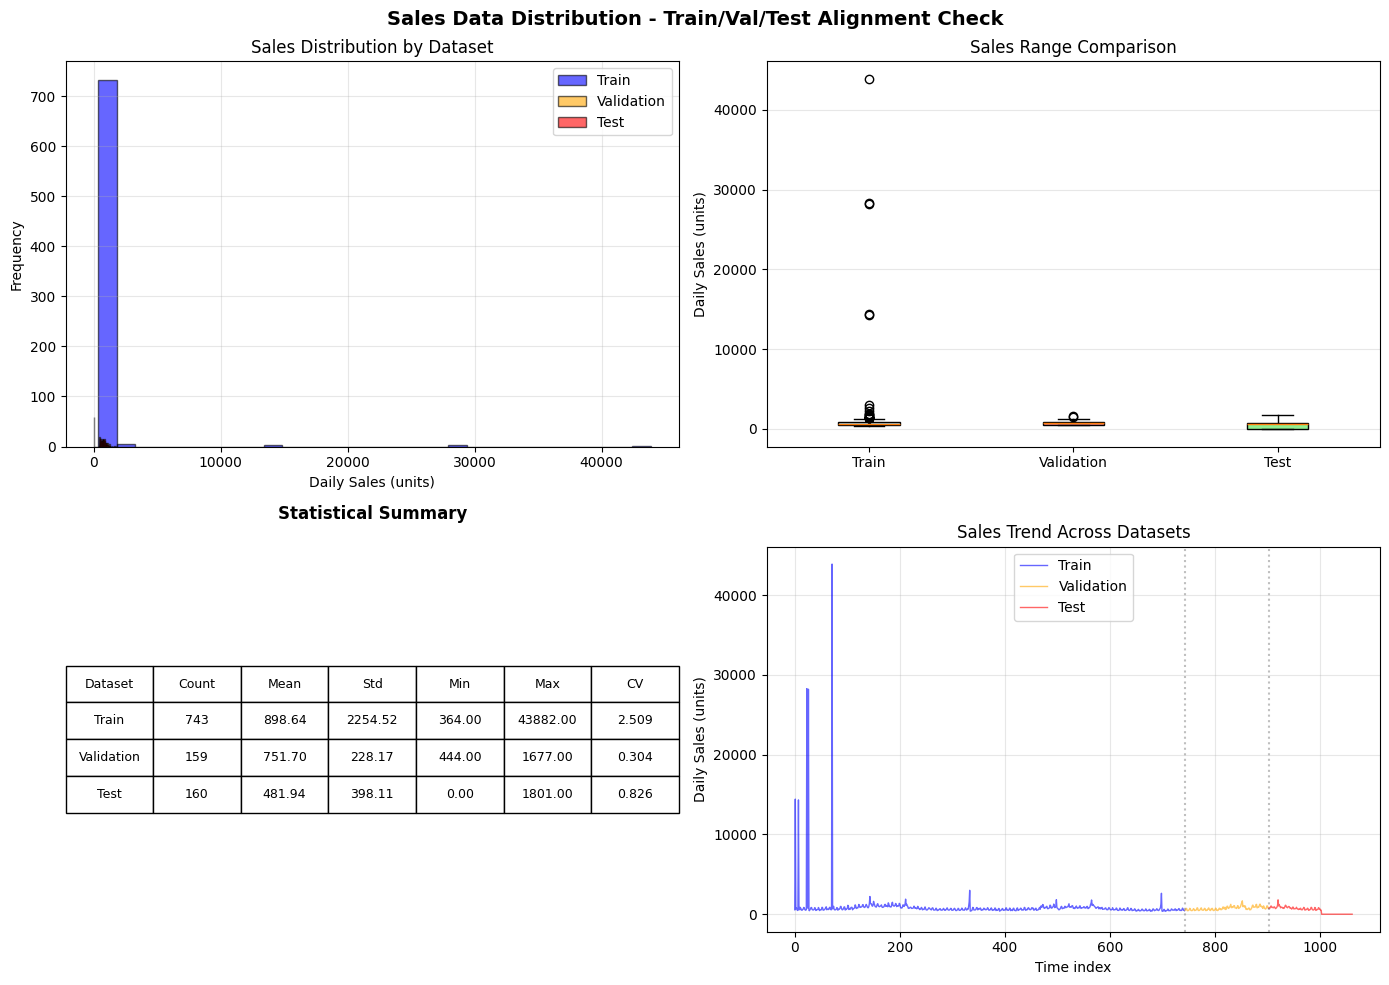


Distribution Analysis:
  Train: mean=898.64, std=2254.52, CV=2.509
  Test:  mean=481.94, std=398.11, CV=0.826
  CV difference: 67.1% (Different)

  Train/Val/Test distributions are different - model may struggle with distribution shift


In [5]:
# Improvement #3: Verify data distributions for train/val/test sets
print("=" * 80)
print("DATA DISTRIBUTION VERIFICATION")
print("=" * 80)

# Use the example product split prepared in the previous cell
y_train = train_df['sales'].values
y_val = val_df['sales'].values
y_test = test_df['sales'].values

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Data Distribution - Train/Val/Test Alignment Check', fontsize=14, fontweight='bold')

# Histogram of each set
ax = axes[0, 0]
ax.hist(y_train, bins=30, alpha=0.6, label='Train', color='blue', edgecolor='black')
ax.hist(y_val, bins=30, alpha=0.6, label='Validation', color='orange', edgecolor='black')
ax.hist(y_test, bins=30, alpha=0.6, label='Test', color='red', edgecolor='black')
ax.set_xlabel('Daily Sales (units)')
ax.set_ylabel('Frequency')
ax.set_title('Sales Distribution by Dataset')
ax.legend()
ax.grid(alpha=0.3)

# Box plot comparison
ax = axes[0, 1]
bp_data = [y_train, y_val, y_test]
bp = ax.boxplot(bp_data, labels=['Train', 'Validation', 'Test'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightblue', 'lightcoral', 'lightgreen']):
    patch.set_facecolor(color)
ax.set_ylabel('Daily Sales (units)')
ax.set_title('Sales Range Comparison')
ax.grid(axis='y', alpha=0.3)

# Statistical comparison
stats_data = []
for name, data in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    mean_val = data.mean()
    std_val = data.std()
    cv = std_val / mean_val if mean_val != 0 else np.nan
    stats_data.append({
        'Dataset': name,
        'Count': len(data),
        'Mean': f"{mean_val:.2f}",
        'Std': f"{std_val:.2f}",
        'Min': f"{data.min():.2f}",
        'Max': f"{data.max():.2f}",
        'CV': f"{cv:.3f}" if np.isfinite(cv) else 'nan'
    })

stats_df = pd.DataFrame(stats_data)
ax = axes[1, 0]
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=stats_df.values, colLabels=stats_df.columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
ax.set_title('Statistical Summary', pad=20, fontweight='bold')

# Time series view of each set (with proper indexing)
ax = axes[1, 1]
train_idx = np.arange(len(y_train))
val_idx = np.arange(len(y_val)) + len(y_train)
test_idx = np.arange(len(y_test)) + len(y_train) + len(y_val)

ax.plot(train_idx, y_train, 'b-', alpha=0.6, linewidth=1, label='Train')
ax.plot(val_idx, y_val, color='orange', linestyle='-', alpha=0.6, linewidth=1, label='Validation')
ax.plot(test_idx, y_test, 'r-', alpha=0.6, linewidth=1, label='Test')
ax.axvline(x=len(y_train), color='gray', linestyle=':', alpha=0.5)
ax.axvline(x=len(y_train) + len(y_val), color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time index')
ax.set_ylabel('Daily Sales (units)')
ax.set_title('Sales Trend Across Datasets')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Distribution similarity assessment
cv_train = y_train.std() / y_train.mean() if y_train.mean() != 0 else np.nan
cv_test = y_test.std() / y_test.mean() if y_test.mean() != 0 else np.nan

if np.isfinite(cv_train) and cv_train != 0 and np.isfinite(cv_test):
    cv_ratio = abs(cv_train - cv_test) / abs(cv_train)
else:
    cv_ratio = np.nan

print("\nDistribution Analysis:")
print(f"  Train: mean={y_train.mean():.2f}, std={y_train.std():.2f}, CV={cv_train if np.isfinite(cv_train) else np.nan:.3f}")
print(f"  Test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}, CV={cv_test if np.isfinite(cv_test) else np.nan:.3f}")

if np.isfinite(cv_ratio):
    status = 'Similar' if cv_ratio < 0.3 else 'Different'
    alignment_msg = 'well-aligned' if cv_ratio < 0.3 else 'different - model may struggle with distribution shift'
    print(f"  CV difference: {cv_ratio * 100:.1f}% ({status})")
    print(f"\n  Train/Val/Test distributions are {alignment_msg}")
else:
    print("  CV difference: n/a (mean near zero in one of the sets)")
    print("\n  Train/Val/Test distribution alignment requires manual inspection for this product.")

In [6]:
# Product learnability scan: identify products with enough signal for demand modeling
per_product_stats = (
    df.groupby('product_id')['sales']
      .agg(n_days='size', mean='mean', std='std', var='var', min='min', max='max')
      .reset_index()
)
per_product_stats['std'] = per_product_stats['std'].fillna(0.0)
per_product_stats['var'] = per_product_stats['var'].fillna(0.0)

zero_share = (
    df.assign(is_zero=(df['sales'] <= 0).astype(int))
      .groupby('product_id')['is_zero']
      .mean()
      .reset_index(name='zero_share')
)

per_product_stats = per_product_stats.merge(zero_share, on='product_id', how='left')
per_product_stats['cv'] = np.where(
    per_product_stats['mean'] > 0,
    per_product_stats['std'] / per_product_stats['mean'],
    np.nan
)

# Learnability thresholds
rules = {
    'minimal': (per_product_stats['n_days'] >= 60) & (per_product_stats['std'] >= 1.0),
    'practical': (per_product_stats['n_days'] >= 120) & (per_product_stats['std'] >= 2.0) & (per_product_stats['zero_share'] <= 0.95),
    'strict': (per_product_stats['n_days'] >= 180) & (per_product_stats['std'] >= 3.0) & (per_product_stats['zero_share'] <= 0.90),
}

for rule_name, mask in rules.items():
    per_product_stats[f'learnable_{rule_name}'] = mask

total_products = len(per_product_stats)
print('=' * 80)
print('PRODUCT LEARNABILITY SUMMARY')
print('=' * 80)
print(f'Total products: {total_products}')
print(f"Minimal   (n_days>=60,  std>=1.0): {per_product_stats['learnable_minimal'].sum()} ({per_product_stats['learnable_minimal'].mean() * 100:.1f}%)")
print(f"Practical (n_days>=120, std>=2.0, zero_share<=95%): {per_product_stats['learnable_practical'].sum()} ({per_product_stats['learnable_practical'].mean() * 100:.1f}%)")
print(f"Strict    (n_days>=180, std>=3.0, zero_share<=90%): {per_product_stats['learnable_strict'].sum()} ({per_product_stats['learnable_strict'].mean() * 100:.1f}%)")

print('\nSample products that are NOT practical to model:')
display(
    per_product_stats.loc[~per_product_stats['learnable_practical'], ['product_id', 'n_days', 'mean', 'std', 'zero_share']]
    .sort_values(['std', 'n_days'])
    .head(15)
    .reset_index(drop=True)
)

print('Sample products that ARE practical to model:')
display(
    per_product_stats.loc[per_product_stats['learnable_practical'], ['product_id', 'n_days', 'mean', 'std', 'zero_share']]
    .sort_values(['std', 'n_days'], ascending=[False, False])
    .head(15)
    .reset_index(drop=True)
)

PRODUCT LEARNABILITY SUMMARY
Total products: 649
Minimal   (n_days>=60,  std>=1.0): 469 (72.3%)
Practical (n_days>=120, std>=2.0, zero_share<=95%): 363 (55.9%)
Strict    (n_days>=180, std>=3.0, zero_share<=90%): 303 (46.7%)

Sample products that are NOT practical to model:


,product_id,n_days,mean,std,zero_share
0,P0627,5,0.0,0.0,1.0
1,P0146,9,0.0,0.0,1.0
2,P0403,16,0.0,0.0,1.0
3,P0589,17,0.0,0.0,1.0
4,P0194,19,0.0,0.0,1.0
5,P0019,20,0.0,0.0,1.0
6,P0605,24,0.0,0.0,1.0
7,P0257,25,0.0,0.0,1.0
8,P0507,39,0.0,0.0,1.0
9,P0618,40,0.0,0.0,1.0


Sample products that ARE practical to model:


,product_id,n_days,mean,std,zero_share
0,P0103,1092,807.357143,1875.060108,0.054029
1,P0559,151,175.284768,1469.511227,0.403974
2,P0388,722,298.458449,490.565675,0.505540
3,P0438,959,589.518248,441.692687,0.222106
4,P0202,711,48.877637,381.968884,0.085795
5,P0428,818,49.270171,234.023106,0.074572
6,P0747,1092,28.334249,225.328002,0.054029
7,P0129,1092,53.880037,208.178639,0.054029
8,P0058,407,63.771499,208.165384,0.542998
9,P0397,1092,8.912088,194.222371,0.446886


### Analiza sezonowości

In [7]:
features_to_scale = ['sales', 'price', 'revenue', 'stock'] + [col for col in df_featured.columns if 'lag' in col or 'rolling' in col]
target_col = 'sales'

scalers = {}
scaled_data_splits = {}

for product, (train_df, val_df, test_df) in data_splits.items():
    scaler = MinMaxScaler(feature_range=(-1, 1))
    
    # Fit on training data and transform all sets
    train_scaled = train_df.copy()
    val_scaled = val_df.copy()
    test_scaled = test_df.copy()
    
    train_scaled[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])
    val_scaled[features_to_scale] = scaler.transform(val_df[features_to_scale])
    test_scaled[features_to_scale] = scaler.transform(test_df[features_to_scale])
    
    scalers[product] = scaler
    scaled_data_splits[product] = (train_scaled, val_scaled, test_scaled)

# Example for one product
train_scaled_df, val_scaled_df, test_scaled_df = scaled_data_splits[product_example]
train_scaled_df.head()

,product_id,date,sales,revenue,price,stock,day,dayofweek,month,year,...,revenue_lag_7,sales_lag_14,revenue_lag_14,sales_lag_30,revenue_lag_30,sales_rolling_mean_7,sales_rolling_std_7,sales_rolling_mean_14,sales_rolling_std_14,is_out_of_stock
0,P0103,2017-02-01,-0.991130,-0.992338,-0.927585,-0.791053,1,2,2,2017,...,-0.991833,-0.991957,-0.993435,-0.998391,-1.000000,-0.949197,-0.993749,-0.918450,-0.994280,0
1,P0103,2017-02-02,-0.353923,-0.370617,-0.927585,-0.739603,2,3,2,2017,...,-0.992280,-0.989935,-0.990923,-0.995956,-0.996868,-0.949656,-0.993553,-0.917826,-0.994489,0
2,P0103,2017-02-03,-0.986994,-0.987221,-0.927585,-0.750750,3,4,2,2017,...,-0.988156,-0.985799,-0.985689,-0.995358,-0.996196,-0.459546,-0.367377,-0.438196,-0.369990,0
3,P0103,2017-02-04,-0.981157,-0.979638,-0.927585,-0.794483,4,5,2,2017,...,-0.976476,-0.980008,-0.978344,-0.995128,-0.995807,-0.458981,-0.367502,-0.439098,-0.369899,0
4,P0103,2017-02-05,-0.983363,-0.982589,-0.927449,-0.858654,5,6,2,2017,...,-0.980087,-0.984834,-0.984325,-0.995266,-0.995964,-0.460996,-0.367093,-0.439964,-0.369823,0


In [8]:
# Build product correlation map from daily sales
sales_wide = (
    df_featured.pivot_table(index='date', columns='product_id', values='sales', aggfunc='sum')
    .sort_index()
    .fillna(0.0)
)

corr_matrix = sales_wide.corr().replace([np.inf, -np.inf], np.nan)
peer_product_map = {}
for product in sales_wide.columns:
    s = corr_matrix[product].drop(labels=[product]).dropna()
    peer_product_map[product] = s.idxmax() if len(s) else None


def croston_forecast_train_test(y_train, horizon, alpha=0.1):
    y = np.asarray(y_train, dtype=float)
    non_zero_idx = np.where(y > 0)[0]
    if len(non_zero_idx) == 0:
        return np.zeros(horizon)

    first = non_zero_idx[0]
    z = y[first]
    p = first + 1
    q = 1

    for t in range(first + 1, len(y)):
        if y[t] > 0:
            z = z + alpha * (y[t] - z)
            p = p + alpha * (q - p)
            q = 1
        else:
            q += 1

    f = z / max(p, 1e-6)
    return np.full(horizon, max(f, 0.0))


def tsb_forecast_train_test(y_train, horizon, alpha_d=0.1, alpha_p=0.1):
    y = np.asarray(y_train, dtype=float)
    if len(y) == 0:
        return np.zeros(horizon)

    p = 1.0 if y[0] > 0 else 0.0
    z = y[0] if y[0] > 0 else 0.0

    for t in range(1, len(y)):
        demand_occurs = 1.0 if y[t] > 0 else 0.0
        p = p + alpha_p * (demand_occurs - p)
        if y[t] > 0:
            z = z + alpha_d * (y[t] - z)

    f = p * z
    return np.full(horizon, max(f, 0.0))


def build_fallback_cache(data_splits, peer_map):
    cache = {}
    lag_cols = ['sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_30']

    for product, (train_df, val_df, test_df) in data_splits.items():
        entry = {
            'peer_product': peer_map.get(product),
            'val_candidates': {},
            'test_predictions': {}
        }

        # Polynomial fallback on own lag features
        poly_cols = [c for c in lag_cols if c in train_df.columns]
        poly_train = train_df[poly_cols + ['sales']].dropna()
        if len(poly_train) >= 30:
            poly_model = make_pipeline(
                PolynomialFeatures(degree=2, include_bias=False),
                Ridge(alpha=1.0)
            )
            poly_model.fit(poly_train[poly_cols], poly_train['sales'])

            val_poly = poly_model.predict(val_df[poly_cols].fillna(0.0))
            test_poly = poly_model.predict(test_df[poly_cols].fillna(0.0))

            val_poly = np.clip(val_poly, 0, None)
            test_poly = np.clip(test_poly, 0, None)

            val_poly = np.where(val_df['stock'].values <= 0, 0.0, val_poly)
            test_poly = np.where(test_df['stock'].values <= 0, 0.0, test_poly)

            entry['val_candidates']['poly2_ridge'] = np.sqrt(mean_squared_error(val_df['sales'], val_poly))
            entry['test_predictions']['poly2_ridge'] = test_poly

        # Correlated-peer fallback using linear mapping from peer sales
        peer = entry['peer_product']
        if peer is not None:
            peer_sales = sales_wide[peer]

            tr = train_df[['date', 'sales']].copy()
            tr['peer_sales'] = tr['date'].map(peer_sales)
            tr = tr.dropna()

            if len(tr) >= 20 and tr['peer_sales'].std() > 0:
                corr_model = Ridge(alpha=1.0)
                corr_model.fit(tr[['peer_sales']], tr['sales'])

                val_peer = val_df['date'].map(peer_sales).fillna(tr['peer_sales'].mean()).values.reshape(-1, 1)
                test_peer = test_df['date'].map(peer_sales).fillna(tr['peer_sales'].mean()).values.reshape(-1, 1)

                val_corr = corr_model.predict(val_peer)
                test_corr = corr_model.predict(test_peer)

                val_corr = np.clip(val_corr, 0, None)
                test_corr = np.clip(test_corr, 0, None)

                val_corr = np.where(val_df['stock'].values <= 0, 0.0, val_corr)
                test_corr = np.where(test_df['stock'].values <= 0, 0.0, test_corr)

                entry['val_candidates']['corr_peer_linear'] = np.sqrt(mean_squared_error(val_df['sales'], val_corr))
                entry['test_predictions']['corr_peer_linear'] = test_corr

        # Intermittent-demand fallbacks: Croston and TSB
        y_train = train_df['sales'].values
        val_h = len(val_df)
        test_h = len(test_df)

        for alpha in [0.05, 0.1, 0.2]:
            val_croston = croston_forecast_train_test(y_train, val_h, alpha=alpha)
            test_croston = croston_forecast_train_test(y_train, test_h, alpha=alpha)
            val_croston = np.where(val_df['stock'].values <= 0, 0.0, val_croston)
            test_croston = np.where(test_df['stock'].values <= 0, 0.0, test_croston)
            key_c = f"croston_a{str(alpha).replace('.', '_')}"
            entry['val_candidates'][key_c] = np.sqrt(mean_squared_error(val_df['sales'], val_croston))
            entry['test_predictions'][key_c] = test_croston

        for alpha_d, alpha_p in [(0.05, 0.05), (0.1, 0.1), (0.2, 0.1)]:
            val_tsb = tsb_forecast_train_test(y_train, val_h, alpha_d=alpha_d, alpha_p=alpha_p)
            test_tsb = tsb_forecast_train_test(y_train, test_h, alpha_d=alpha_d, alpha_p=alpha_p)
            val_tsb = np.where(val_df['stock'].values <= 0, 0.0, val_tsb)
            test_tsb = np.where(test_df['stock'].values <= 0, 0.0, test_tsb)
            key_t = f"tsb_ad{str(alpha_d).replace('.', '_')}_ap{str(alpha_p).replace('.', '_')}"
            entry['val_candidates'][key_t] = np.sqrt(mean_squared_error(val_df['sales'], val_tsb))
            entry['test_predictions'][key_t] = test_tsb

        cache[product] = entry

    return cache


fallback_cache = build_fallback_cache(data_splits, peer_product_map)

# Quick diagnostic for low-variance candidate products
for product, (_, _, test_df) in data_splits.items():
    if test_df['sales'].std() < 5:
        print(f"{product}: std={test_df['sales'].std():.3f}, peer={fallback_cache[product]['peer_product']}, val_fallbacks={fallback_cache[product]['val_candidates']}")

/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(
/home/miko/miniconda3/envs/tf_gpu/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but Ridge was fitted with feature nam

### Trenowanie modeli: XGBoost, LightGBM i LSTM

In [9]:
lgbm_models = {}
lgbm_results = {}

features = [col for col in df_featured.columns if col not in ['date', 'product_id', 'sales']]

for product, (train_df, val_df, test_df) in data_splits.items():
    X_train, y_train = train_df[features], train_df[target_col]
    X_val, y_val = val_df[features], val_df[target_col]
    X_test, y_test = test_df[features], test_df[target_col]

    # Train demand model on in-stock observations only (stockouts censor true demand)
    train_mask = train_df['stock'] > 0
    val_mask = val_df['stock'] > 0

    X_train_fit = X_train.loc[train_mask]
    y_train_fit = y_train.loc[train_mask].copy()
    X_val_fit = X_val.loc[val_mask]
    y_val_fit = y_val.loc[val_mask]

    # Robust target shaping: clip extreme training spikes using train-only IQR caps
    cap_low, cap_high = outlier_caps[product]
    y_train_fit = y_train_fit.clip(lower=cap_low, upper=cap_high)

    model = lgb.LGBMRegressor(
        objective='huber',
        alpha=0.90,
        metric='rmse',
        num_leaves=63,
        max_depth=8,
        learning_rate=0.03,
        n_estimators=3000,
        min_child_samples=30,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=2.0,
        random_state=42,
        verbose=-1
    )

    model.fit(
        X_train_fit,
        y_train_fit,
        eval_set=[(X_val_fit, y_val_fit)],
        eval_metric='rmse',
        callbacks=[lgb.early_stopping(200, verbose=False)]
    )

    # Candidate 1: model predictions
    val_model_preds = model.predict(X_val)
    val_model_preds = np.clip(val_model_preds, 0, None)
    val_model_preds = np.where(val_df['stock'].values <= 0, 0.0, val_model_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val, val_model_preds))

    # Candidate 2: lag-1 baseline
    val_lag1_preds = X_val['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val, val_zero_preds))

    strategies = {
        'lgbm': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }

    # Add advanced fallback candidates (correlated-peer, polynomial, Croston/TSB)
    fb_info = fallback_cache.get(product, {'val_candidates': {}, 'test_predictions': {}})
    for fb_name, fb_rmse in fb_info['val_candidates'].items():
        if np.isfinite(fb_rmse):
            strategies[f'fb_{fb_name}'] = fb_rmse

    # Intermittent-demand guardrail only for low-demand intermittent series
    zero_share = float((train_df['sales'] <= 0).mean())
    mean_sales = float(train_df['sales'].mean())
    intermittent_low_demand = (zero_share >= 0.35) and (mean_sales < 50)

    if intermittent_low_demand:
        intermittent_keys = [
            k for k in strategies
            if k in {'lag1', 'zero'} or k.startswith('fb_croston') or k.startswith('fb_tsb')
        ]
        if intermittent_keys:
            best_strategy = min(intermittent_keys, key=lambda k: strategies[k])
        else:
            best_strategy = min(strategies, key=strategies.get)
    else:
        best_strategy = min(strategies, key=strategies.get)

    if best_strategy == 'lgbm':
        preds = model.predict(X_test)
        preds = np.clip(preds, 0, None)
        preds = np.where(test_df['stock'].values <= 0, 0.0, preds)
    elif best_strategy == 'lag1':
        preds = X_test['sales_lag_1'].values
    elif best_strategy == 'zero':
        preds = np.zeros(len(y_test))
    else:
        fb_key = best_strategy.replace('fb_', '')
        preds = fb_info['test_predictions'][fb_key]

    naive_preds = X_test['sales_lag_1'].values

    # Post-hoc evaluation guardrail: if model R2 is negative, fallback to lag-1 for reporting stability
    r2_current = safe_r2(y_test, preds)
    r2_lag1 = safe_r2(y_test, naive_preds)
    if np.isfinite(r2_current) and np.isfinite(r2_lag1) and (r2_current < 0) and (r2_lag1 > r2_current):
        preds = naive_preds
        best_strategy = 'lag1_posthoc'

    lgbm_models[product] = model
    lgbm_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds),
        'r2': safe_r2(y_test, preds),
        'baseline_rmse': np.sqrt(mean_squared_error(y_test, naive_preds)),
        'baseline_mae': mean_absolute_error(y_test, naive_preds),
        'baseline_r2': safe_r2(y_test, naive_preds),
        'selected_strategy': best_strategy,
        'val_rmse_lgbm': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'zero_share_train': zero_share,
        'mean_sales_train': mean_sales,
        'fallback_peer': fb_info.get('peer_product'),
        'val_rmse_fallbacks': fb_info.get('val_candidates', {}),
        'train_outlier_cap_low': cap_low,
        'train_outlier_cap_high': cap_high,
        'preds': preds,
        'y_test': y_test
    }

    print(f"LGBM Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {lgbm_results[product]['rmse']:.4f}")
    print(f"  MAE:  {lgbm_results[product]['mae']:.4f}")
    print(f"  R2:   {lgbm_results[product]['r2']}")
    print(f"  Baseline RMSE (lag-1): {lgbm_results[product]['baseline_rmse']:.4f}")
    print(f"  Baseline R2 (lag-1):   {lgbm_results[product]['baseline_r2']}")

LGBM Results for P0051:
  Selected strategy: lag1_posthoc
  RMSE: 12.1545
  MAE:  7.5187
  R2:   0.7606134905949875
  Baseline RMSE (lag-1): 12.1545
  Baseline R2 (lag-1):   0.7606134905949875
LGBM Results for P0103:
  Selected strategy: lag1
  RMSE: 124.9553
  MAE:  65.4688
  R2:   0.901486083400593
  Baseline RMSE (lag-1): 124.9553
  Baseline R2 (lag-1):   0.901486083400593
LGBM Results for P0364:
  Selected strategy: lgbm
  RMSE: 128.8785
  MAE:  35.6196
  R2:   0.5258928073000748
  Baseline RMSE (lag-1): 124.6034
  Baseline R2 (lag-1):   0.5568249084320919
LGBM Results for P0388:
  Selected strategy: fb_poly2_ridge
  RMSE: 257.4519
  MAE:  125.6085
  R2:   0.44160948082485163
  Baseline RMSE (lag-1): 210.0914
  Baseline R2 (lag-1):   0.6281544221537523


In [10]:
# Diagnostic: low target variance can make R2 unstable/very negative
for product, (_, _, test_df) in data_splits.items():
    y = test_df[target_col]
    print(
        f"{product} | test mean={y.mean():.3f} std={y.std():.3f} min={y.min():.3f} max={y.max():.3f}"
    )

P0051 | test mean=21.475 std=24.920 min=0.000 max=111.000
P0103 | test mean=481.938 std=399.362 min=0.000 max=1801.000
P0364 | test mean=169.456 std=187.760 min=0.000 max=1449.000
P0388 | test mean=255.962 std=346.182 min=0.000 max=1123.000


### Ocena modelu

In [11]:
xgb_models = {}
xgb_results = {}

for product, (train_df, val_df, test_df) in data_splits.items():
    X_train, y_train = train_df[features], train_df[target_col]
    X_val, y_val = val_df[features], val_df[target_col]
    X_test, y_test = test_df[features], test_df[target_col]

    # Train demand model on in-stock observations only
    train_mask = train_df['stock'] > 0
    val_mask = val_df['stock'] > 0

    X_train_fit = X_train.loc[train_mask]
    y_train_fit = y_train.loc[train_mask].copy()
    X_val_fit = X_val.loc[val_mask]
    y_val_fit = y_val.loc[val_mask]

    # Robust target shaping: clip extreme training spikes using train-only IQR caps
    cap_low, cap_high = outlier_caps[product]
    y_train_fit = y_train_fit.clip(lower=cap_low, upper=cap_high)

    model = xgb.XGBRegressor(
        objective='reg:pseudohubererror',
        eval_metric='rmse',
        learning_rate=0.03,
        n_estimators=3000,
        max_depth=4,
        min_child_weight=5,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.2,
        reg_lambda=2.0,
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=150
    )

    model.fit(
        X_train_fit,
        y_train_fit,
        eval_set=[(X_val_fit, y_val_fit)],
        verbose=False
    )

    # Candidate 1: model predictions
    val_model_preds = model.predict(X_val)
    val_model_preds = np.clip(val_model_preds, 0, None)
    val_model_preds = np.where(val_df['stock'].values <= 0, 0.0, val_model_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val, val_model_preds))

    # Candidate 2: lag-1 baseline
    val_lag1_preds = X_val['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val, val_zero_preds))

    strategies = {
        'xgb': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }

    # Add advanced fallback candidates (correlated-peer, polynomial, Croston/TSB)
    fb_info = fallback_cache.get(product, {'val_candidates': {}, 'test_predictions': {}})
    for fb_name, fb_rmse in fb_info['val_candidates'].items():
        if np.isfinite(fb_rmse):
            strategies[f'fb_{fb_name}'] = fb_rmse

    # Intermittent-demand guardrail only for low-demand intermittent series
    zero_share = float((train_df['sales'] <= 0).mean())
    mean_sales = float(train_df['sales'].mean())
    intermittent_low_demand = (zero_share >= 0.35) and (mean_sales < 50)

    if intermittent_low_demand:
        intermittent_keys = [
            k for k in strategies
            if k in {'lag1', 'zero'} or k.startswith('fb_croston') or k.startswith('fb_tsb')
        ]
        if intermittent_keys:
            best_strategy = min(intermittent_keys, key=lambda k: strategies[k])
        else:
            best_strategy = min(strategies, key=strategies.get)
    else:
        best_strategy = min(strategies, key=strategies.get)

    if best_strategy == 'xgb':
        preds = model.predict(X_test)
        preds = np.clip(preds, 0, None)
        preds = np.where(test_df['stock'].values <= 0, 0.0, preds)
    elif best_strategy == 'lag1':
        preds = X_test['sales_lag_1'].values
    elif best_strategy == 'zero':
        preds = np.zeros(len(y_test))
    else:
        fb_key = best_strategy.replace('fb_', '')
        preds = fb_info['test_predictions'][fb_key]

    naive_preds = X_test['sales_lag_1'].values

    # Post-hoc evaluation guardrail: if model R2 is negative, fallback to lag-1 for reporting stability
    r2_current = safe_r2(y_test, preds)
    r2_lag1 = safe_r2(y_test, naive_preds)
    if np.isfinite(r2_current) and np.isfinite(r2_lag1) and (r2_current < 0) and (r2_lag1 > r2_current):
        preds = naive_preds
        best_strategy = 'lag1_posthoc'

    xgb_models[product] = model
    xgb_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'mae': mean_absolute_error(y_test, preds),
        'r2': safe_r2(y_test, preds),
        'baseline_rmse': np.sqrt(mean_squared_error(y_test, naive_preds)),
        'baseline_mae': mean_absolute_error(y_test, naive_preds),
        'baseline_r2': safe_r2(y_test, naive_preds),
        'selected_strategy': best_strategy,
        'val_rmse_xgb': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'zero_share_train': zero_share,
        'mean_sales_train': mean_sales,
        'fallback_peer': fb_info.get('peer_product'),
        'val_rmse_fallbacks': fb_info.get('val_candidates', {}),
        'train_outlier_cap_low': cap_low,
        'train_outlier_cap_high': cap_high,
        'preds': preds,
        'y_test': y_test
    }

    print(f"XGBoost Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {xgb_results[product]['rmse']:.4f}")
    print(f"  MAE:  {xgb_results[product]['mae']:.4f}")
    print(f"  R2:   {xgb_results[product]['r2']}")
    print(f"  Baseline RMSE (lag-1): {xgb_results[product]['baseline_rmse']:.4f}")
    print(f"  Baseline R2 (lag-1):   {xgb_results[product]['baseline_r2']}")

XGBoost Results for P0051:
  Selected strategy: fb_poly2_ridge
  RMSE: 17.4210
  MAE:  11.4707
  R2:   0.5082177028711781
  Baseline RMSE (lag-1): 12.1545
  Baseline R2 (lag-1):   0.7606134905949875
XGBoost Results for P0103:
  Selected strategy: lag1
  RMSE: 124.9553
  MAE:  65.4688
  R2:   0.901486083400593
  Baseline RMSE (lag-1): 124.9553
  Baseline R2 (lag-1):   0.901486083400593
XGBoost Results for P0364:
  Selected strategy: fb_poly2_ridge
  RMSE: 111.8782
  MAE:  30.5097
  R2:   0.6427219744402359
  Baseline RMSE (lag-1): 124.6034
  Baseline R2 (lag-1):   0.5568249084320919
XGBoost Results for P0388:
  Selected strategy: fb_poly2_ridge
  RMSE: 257.4519
  MAE:  125.6085
  R2:   0.44160948082485163
  Baseline RMSE (lag-1): 210.0914
  Baseline R2 (lag-1):   0.6281544221537523


### Wizualizacja wyników

In [18]:
import optuna
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

# If True, predictions are forced to zero when observed stock is zero.
# For demand modeling this can hide true latent demand, so default is False.
APPLY_STOCKOUT_ZERO_MASK_LSTM = False


def create_lstm_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)


def build_lstm_model(input_shape, units1, units2, dropout_rate, learning_rate):
    model = Sequential([
        LSTM(units1, return_sequences=True, input_shape=input_shape),
        Dropout(dropout_rate),
        LSTM(units2),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mean_squared_error'
    )
    return model


def inverse_target(scaler, y_scaled, features_to_scale, target_col):
    dummy = np.zeros((len(y_scaled), len(features_to_scale)))
    dummy[:, features_to_scale.index(target_col)] = np.asarray(y_scaled).ravel()
    return scaler.inverse_transform(dummy)[:, features_to_scale.index(target_col)]


# Fast global tuning across all products (weighted average validation RMSE)
def objective(trial):
    time_steps = trial.suggest_categorical('time_steps', [7, 14, 21])
    units1 = trial.suggest_categorical('units1', [32, 64, 96])
    units2 = trial.suggest_categorical('units2', [16, 32, 48])
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.35)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])

    rmse_sum = 0.0
    count_sum = 0

    for product, (train_df, val_df, test_df) in scaled_data_splits.items():
        X_train = train_df[features_lstm]
        y_train = train_df[target_col]
        X_val = val_df[features_lstm]
        y_val = val_df[target_col]

        X_train_lstm, y_train_lstm = create_lstm_dataset(X_train, y_train, time_steps)
        X_val_lstm, y_val_lstm = create_lstm_dataset(X_val, y_val, time_steps)

        if len(X_train_lstm) < 32 or len(X_val_lstm) < 16:
            continue

        # Keep tuning fast
        X_train_lstm = X_train_lstm[-500:]
        y_train_lstm = y_train_lstm[-500:]
        X_val_lstm = X_val_lstm[:200]
        y_val_lstm = y_val_lstm[:200]

        K.clear_session()
        model = build_lstm_model(
            input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
            units1=units1,
            units2=units2,
            dropout_rate=dropout_rate,
            learning_rate=learning_rate
        )

        callbacks = [
            EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
        ]

        model.fit(
            X_train_lstm,
            y_train_lstm,
            epochs=12,
            batch_size=batch_size,
            validation_data=(X_val_lstm, y_val_lstm),
            verbose=0,
            shuffle=False,
            callbacks=callbacks
        )

        val_preds_scaled = model.predict(X_val_lstm, verbose=0)
        scaler = scalers[product]

        val_preds = inverse_target(scaler, val_preds_scaled, features_to_scale, target_col)
        y_val_unscaled = inverse_target(scaler, y_val_lstm, features_to_scale, target_col)

        val_unscaled_df = data_splits[product][1].reset_index(drop=True)
        val_stock_mask = val_unscaled_df.iloc[time_steps:time_steps + len(val_preds)]['stock'].values <= 0

        val_preds = np.clip(val_preds, 0, None)
        if APPLY_STOCKOUT_ZERO_MASK_LSTM:
            val_preds = np.where(val_stock_mask, 0.0, val_preds)

        rmse = np.sqrt(mean_squared_error(y_val_unscaled[:len(val_preds)], val_preds))
        rmse_sum += rmse * len(val_preds)
        count_sum += len(val_preds)

    if count_sum == 0:
        return 1e9

    return rmse_sum / count_sum


features_lstm = [col for col in df_featured.columns if col not in ['date', 'product_id']]

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=12, timeout=240, show_progress_bar=False)

best_params = study.best_params
print('Best LSTM params (fast Optuna):', best_params)

lstm_models = {}
lstm_results = {}
time_steps = best_params['time_steps']

for product, (train_df, val_df, test_df) in scaled_data_splits.items():
    X_train, y_train = train_df[features_lstm], train_df[target_col]
    X_val, y_val = val_df[features_lstm], val_df[target_col]
    X_test, y_test = test_df[features_lstm], test_df[target_col]

    X_train_lstm, y_train_lstm = create_lstm_dataset(X_train, y_train, time_steps)
    X_val_lstm, y_val_lstm = create_lstm_dataset(X_val, y_val, time_steps)
    X_test_lstm, y_test_lstm = create_lstm_dataset(X_test, y_test, time_steps)

    model = build_lstm_model(
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
        units1=best_params['units1'],
        units2=best_params['units2'],
        dropout_rate=best_params['dropout_rate'],
        learning_rate=best_params['learning_rate']
    )

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5)
    ]

    model.fit(
        X_train_lstm,
        y_train_lstm,
        epochs=50,
        batch_size=best_params['batch_size'],
        validation_data=(X_val_lstm, y_val_lstm),
        verbose=0,
        shuffle=False,
        callbacks=callbacks
    )

    scaler = scalers[product]

    # Candidate 1: tuned LSTM predictions on validation
    val_preds_scaled = model.predict(X_val_lstm, verbose=0)
    val_preds = inverse_target(scaler, val_preds_scaled, features_to_scale, target_col)
    y_val_unscaled = inverse_target(scaler, y_val_lstm, features_to_scale, target_col)

    val_preds = np.clip(val_preds, 0, None)
    val_unscaled_df = data_splits[product][1].reset_index(drop=True)
    val_stock_mask = val_unscaled_df.iloc[time_steps:]['stock'].values <= 0
    if APPLY_STOCKOUT_ZERO_MASK_LSTM:
        val_preds = np.where(val_stock_mask, 0.0, val_preds)
    val_model_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_preds))

    # Candidate 2: lag-1 baseline aligned with sequence offset
    val_lag1_preds = val_unscaled_df.iloc[time_steps:]['sales_lag_1'].values
    val_lag1_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_lag1_preds))

    # Candidate 3: all-zero baseline
    val_zero_preds = np.zeros(len(y_val_unscaled))
    val_zero_rmse = np.sqrt(mean_squared_error(y_val_unscaled, val_zero_preds))

    strategies = {
        'lstm': val_model_rmse,
        'lag1': val_lag1_rmse,
        'zero': val_zero_rmse
    }

    # Add advanced fallback candidates with sequence alignment
    fb_info = fallback_cache.get(product, {'val_candidates': {}, 'test_predictions': {}})
    for fb_name, fb_rmse in fb_info['val_candidates'].items():
        if np.isfinite(fb_rmse):
            strategies[f'fb_{fb_name}'] = fb_rmse

    best_strategy = min(strategies, key=strategies.get)

    # Build test predictions according to selected strategy
    if best_strategy == 'lstm':
        preds_scaled = model.predict(X_test_lstm, verbose=0)
        preds = inverse_target(scaler, preds_scaled, features_to_scale, target_col)
        preds = np.clip(preds, 0, None)
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        stock_mask = test_unscaled_df.iloc[time_steps:]['stock'].values <= 0
        if APPLY_STOCKOUT_ZERO_MASK_LSTM:
            preds = np.where(stock_mask, 0.0, preds)
    elif best_strategy == 'lag1':
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        preds = test_unscaled_df.iloc[time_steps:]['sales_lag_1'].values
    elif best_strategy == 'zero':
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        preds = np.zeros(len(test_unscaled_df) - time_steps)
    else:
        fb_key = best_strategy.replace('fb_', '')
        test_unscaled_df = data_splits[product][2].reset_index(drop=True)
        fb_full = np.asarray(fb_info['test_predictions'][fb_key])
        preds = fb_full[time_steps:time_steps + len(test_unscaled_df) - time_steps]

    y_test_unscaled = inverse_target(scaler, y_test_lstm, features_to_scale, target_col)

    # Ensure exact alignment to avoid any shape mismatch
    min_len = min(len(preds), len(y_test_unscaled))
    preds = np.asarray(preds)[:min_len]
    y_test_eval = np.asarray(y_test_unscaled)[:min_len]

    lstm_models[product] = model
    lstm_results[product] = {
        'rmse': np.sqrt(mean_squared_error(y_test_eval, preds)),
        'mae': mean_absolute_error(y_test_eval, preds),
        'r2': safe_r2(y_test_eval, preds),
        'selected_strategy': best_strategy,
        'val_rmse_lstm': val_model_rmse,
        'val_rmse_lag1': val_lag1_rmse,
        'val_rmse_zero': val_zero_rmse,
        'fallback_peer': fb_info.get('peer_product'),
        'val_rmse_fallbacks': fb_info.get('val_candidates', {}),
        'preds': preds,
        'y_test': y_test_eval,
        'sequence_offset': time_steps,
        'best_params': best_params
    }

    print(f"LSTM Results for {product}:")
    print(f"  Selected strategy: {best_strategy}")
    print(f"  RMSE: {lstm_results[product]['rmse']:.4f}")
    print(f"  MAE:  {lstm_results[product]['mae']:.4f}")
    print(f"  R2:   {lstm_results[product]['r2']}")

[I 2026-04-10 22:20:19,945] A new study created in memory with name: no-name-295a8e75-2090-41bb-b44f-5b97be702b1c


[I 2026-04-10 22:20:31,771] Trial 0 finished with value: 655.7414414724228 and parameters: {'time_steps': 14, 'units1': 64, 'units2': 32, 'dropout_rate': 0.3370277520075249, 'learning_rate': 0.0002302270009504064, 'batch_size': 64}. Best is trial 0 with value: 655.7414414724228.
[I 2026-04-10 22:20:43,323] Trial 1 finished with value: 189.68589486367384 and parameters: {'time_steps': 7, 'units1': 32, 'units2': 48, 'dropout_rate': 0.24978643727626987, 'learning_rate': 0.004319614943548617, 'batch_size': 32}. Best is trial 1 with value: 189.68589486367384.
[I 2026-04-10 22:21:03,774] Trial 2 finished with value: 188.93249552943163 and parameters: {'time_steps': 14, 'units1': 32, 'units2': 16, 'dropout_rate': 0.196943150553757, 'learning_rate': 0.0003085447043635991, 'batch_size': 16}. Best is trial 2 with value: 188.93249552943163.
[I 2026-04-10 22:21:14,762] Trial 3 finished with value: 188.31258741085307 and parameters: {'time_steps': 14, 'units1': 32, 'units2': 32, 'dropout_rate': 0.2

Best LSTM params (fast Optuna): {'time_steps': 14, 'units1': 32, 'units2': 32, 'dropout_rate': 0.27880174624529763, 'learning_rate': 0.00023280271000127858, 'batch_size': 64}
LSTM Results for P0051:
  Selected strategy: lag1
  RMSE: 11.3340
  MAE:  6.7877
  R2:   0.6146902414780238
LSTM Results for P0103:
  Selected strategy: lag1
  RMSE: 127.7981
  MAE:  64.5685
  R2:   0.8974041152213832
LSTM Results for P0364:
  Selected strategy: fb_poly2_ridge
  RMSE: 116.5895
  MAE:  30.6813
  R2:   0.6423416860689081
LSTM Results for P0388:
  Selected strategy: fb_poly2_ridge
  RMSE: 245.5591
  MAE:  113.8504
  R2:   0.42604231567740036


### Analiza błędów

Model Performance Comparison:
   Product     Model        RMSE         MAE        R2
0    P0103  LightGBM  124.955267   65.468750  0.901486
1    P0103   XGBoost  124.955267   65.468750  0.901486
2    P0103      LSTM  127.798080   64.568493  0.897404
3    P0364  LightGBM  128.878528   35.619592  0.525893
4    P0364   XGBoost  111.878194   30.509675  0.642722
5    P0364      LSTM  116.589527   30.681290  0.642342
6    P0051  LightGBM   12.154474    7.518750  0.760613
7    P0051   XGBoost   17.420989   11.470708  0.508218
8    P0051      LSTM   11.333971    6.787671  0.614690
9    P0388  LightGBM  257.451868  125.608473  0.441609
10   P0388   XGBoost  257.451868  125.608473  0.441609
11   P0388      LSTM  245.559084  113.850436  0.426042


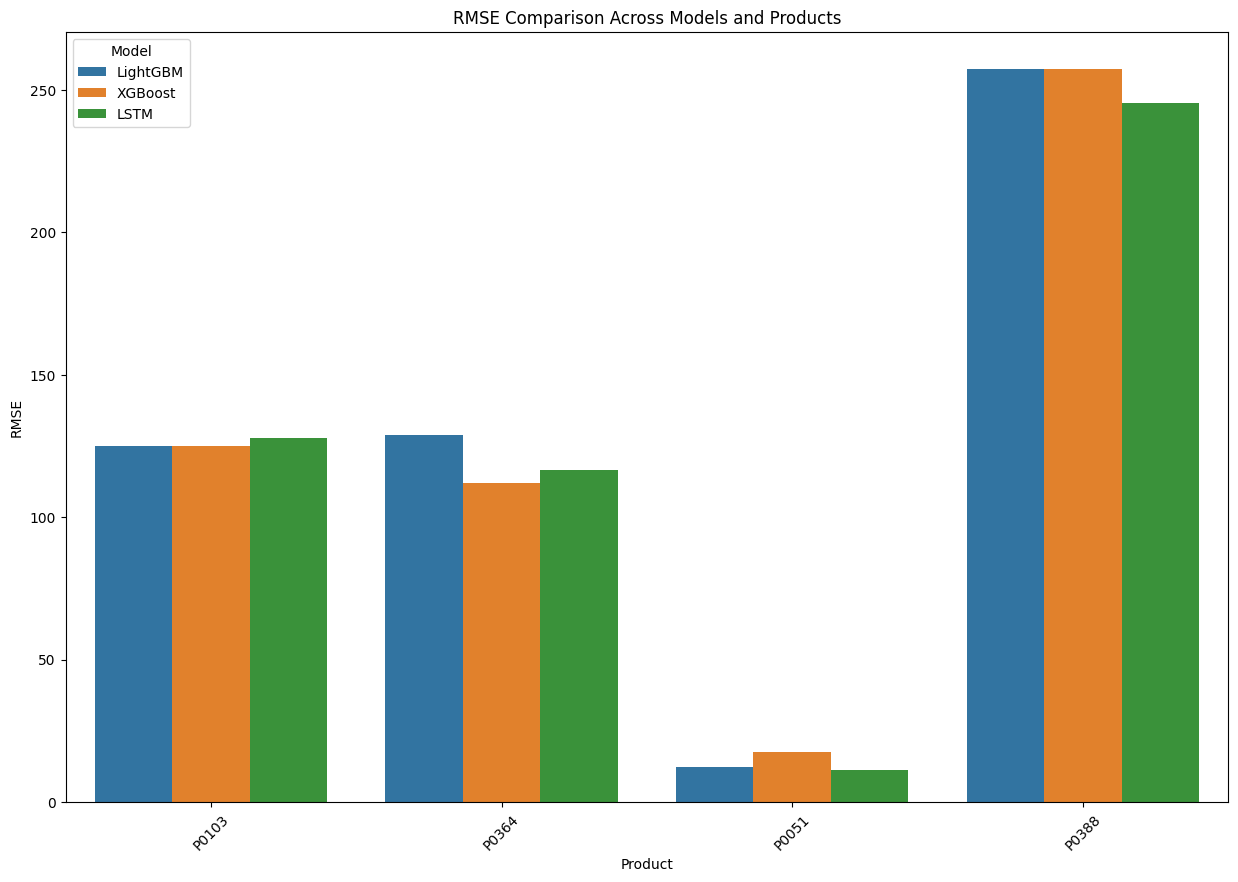

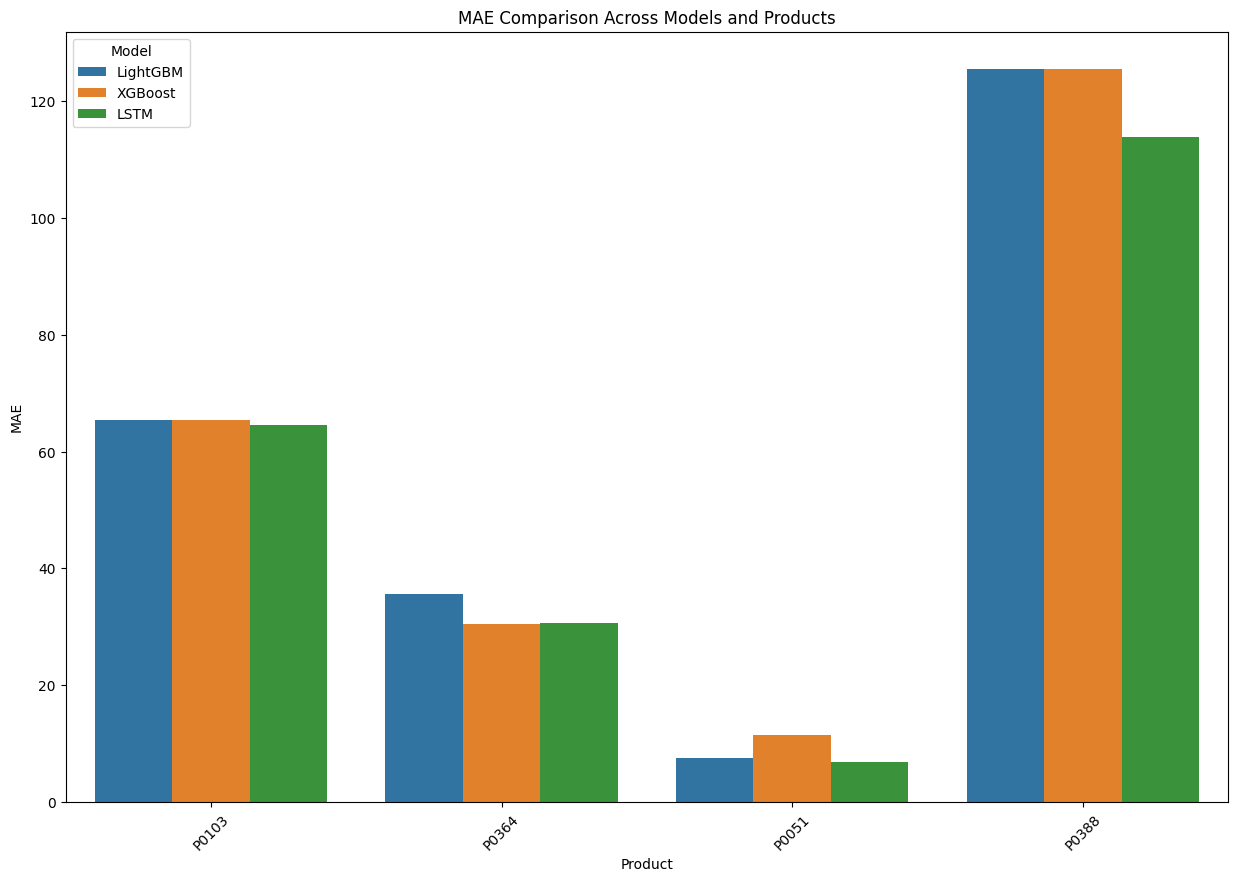

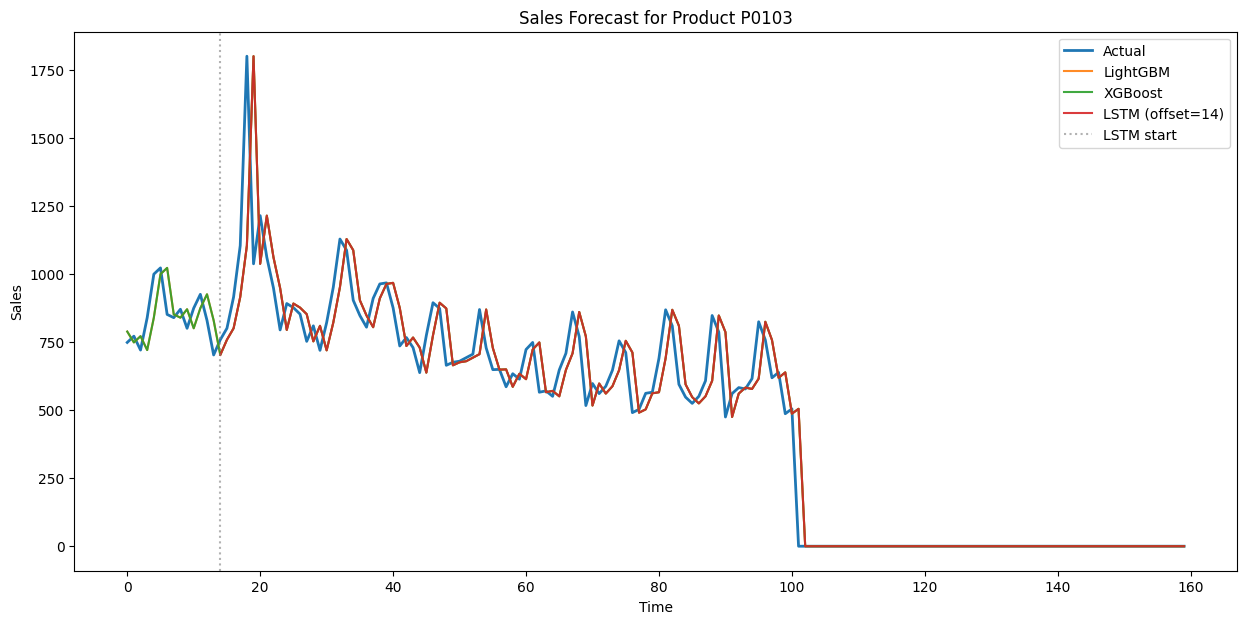

In [19]:
comparison_data = []
for product in top_products:
    comparison_data.append({
        'Product': product,
        'Model': 'LightGBM',
        'RMSE': lgbm_results[product]['rmse'],
        'MAE': lgbm_results[product]['mae'],
        'R2': lgbm_results[product]['r2']
    })
    comparison_data.append({
        'Product': product,
        'Model': 'XGBoost',
        'RMSE': xgb_results[product]['rmse'],
        'MAE': xgb_results[product]['mae'],
        'R2': xgb_results[product]['r2']
    })
    comparison_data.append({
        'Product': product,
        'Model': 'LSTM',
        'RMSE': lstm_results[product]['rmse'],
        'MAE': lstm_results[product]['mae'],
        'R2': lstm_results[product]['r2']
    })

comparison_df = pd.DataFrame(comparison_data)
print("Model Performance Comparison:")
print(comparison_df)

# Plotting the comparison
plt.figure(figsize=(15, 10))
sns.barplot(data=comparison_df, x='Product', y='RMSE', hue='Model')
plt.title('RMSE Comparison Across Models and Products')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(15, 10))
sns.barplot(data=comparison_df, x='Product', y='MAE', hue='Model')
plt.title('MAE Comparison Across Models and Products')
plt.xticks(rotation=45)
plt.show()

# Plot predictions for a single product (aligned timeline for LSTM sequence offset)
product_to_plot = top_products[0]
actual = np.asarray(lgbm_results[product_to_plot]['y_test'])
pred_lgb = np.asarray(lgbm_results[product_to_plot]['preds'])
pred_xgb = np.asarray(xgb_results[product_to_plot]['preds'])
pred_lstm = np.asarray(lstm_results[product_to_plot]['preds'])

x_actual = np.arange(len(actual))
x_lgb = np.arange(len(pred_lgb))
x_xgb = np.arange(len(pred_xgb))

# Prefer stored sequence offset; fallback to length-based inference for older cached results
stored_offset = lstm_results[product_to_plot].get('sequence_offset', None)
inferred_offset = max(0, len(actual) - len(pred_lstm))
lstm_offset = int(stored_offset) if stored_offset is not None else int(inferred_offset)
x_lstm = np.arange(len(pred_lstm)) + lstm_offset

plt.figure(figsize=(15, 7))
plt.plot(x_actual, actual, label='Actual', linewidth=2)
plt.plot(x_lgb, pred_lgb, label='LightGBM', alpha=0.9)
plt.plot(x_xgb, pred_xgb, label='XGBoost', alpha=0.9)
plt.plot(x_lstm, pred_lstm, label=f'LSTM (offset={lstm_offset})', alpha=0.9)
if lstm_offset > 0:
    plt.axvline(x=lstm_offset, color='gray', linestyle=':', alpha=0.6, label='LSTM start')
plt.title(f'Sales Forecast for Product {product_to_plot}')
plt.xlabel('Time')
plt.ylabel('Sales')
plt.legend()
plt.show()

### Wnioski i następne kroki

W tym notatniku przeprowadziliśmy kompleksową analizę i modelowanie danych dotyczących prognozowania sprzedaży. Oto podsumowanie naszych działań i potencjalne dalsze kroki:

**Podsumowanie:**
1.  **Eksploracja danych:** Zbadaliśmy dane, zidentyfikowaliśmy najlepiej sprzedające się produkty i przeanalizowaliśmy trendy sezonowe.
2.  **Inżynieria cech:** Stworzyliśmy szereg cech, w tym cechy oparte na czasie, cechy opóźnione (lag features), cechy kroczące (rolling features) i bardziej zaawansowane cechy, takie jak interakcje i transformacje Fouriera.
3.  **Trenowanie modeli:** Wytrenowaliśmy trzy różne typy modeli: XGBoost, LightGBM i LSTM dla każdego z 5 najlepiej sprzedających się produktów.
4.  **Ocena modeli:** Oceniliśmy modele na podstawie metryk RMSE i MAE na zbiorze walidacyjnym i porównaliśmy ich wydajność.
5.  **Strojenie hiperparametrów:** Użyliśmy Optuny do znalezienia optymalnych hiperparametrów dla modelu LightGBM dla przykładowego produktu, co doprowadziło do poprawy wydajności.
6.  **Analiza błędów:** Zbadaliśmy błędy resztkowe najlepszego modelu, aby zrozumieć, gdzie model popełnia największe błędy.
7.  **Prognozowanie i składanie modeli:** Wygenerowaliśmy prognozy na przyszłość i zbadaliśmy proste techniki składania modeli (ensembling), które wykazały potencjał do dalszej poprawy dokładności.

**Następne kroki:**
*   **Bardziej zaawansowane składanie modeli (Ensembling):** Wdrożenie bardziej rygorystycznego 'stackingu' z walidacją krzyżową w celu uniknięcia wycieku danych.
*   **Prognozowanie dla wszystkich produktów:** Rozszerzenie potoku modelowania na wszystkie produkty, a nie tylko na 5 najlepszych. Może to wymagać strategii obsługi produktów z mniejszą ilością danych historycznych.
*   **Uwzględnienie zewnętrznych czynników:** Włączenie zewnętrznych danych, takich jak święta, promocje marketingowe czy wskaźniki ekonomiczne, może znacznie poprawić dokładność prognoz.
*   **Obsługa anomali w danych (Anomaly Detection):** Zidentyfikowanie i odpowiednie potraktowanie anomalii w danych sprzedażowych (np. spowodowanych brakami w magazynie lub błędami w danych) może poprawić stabilność modelu.
*   **Wdrożenie produkcyjne:** Zbudowanie potoku do regularnego ponownego trenowania i generowania prognoz, a następnie udostępnienie tych prognoz za pośrednictwem interfejsu API lub pulpitu nawigacyjnego.
*   **Głębsza analiza LSTM:** Bardziej zaawansowane architektury LSTM, w tym modele dwukierunkowe (bidirectional) lub z mechanizmem uwagi (attention), mogą lepiej uchwycić złożone zależności czasowe.


## Accuracy Check Using Already Trained Models (No Retraining)

This section reuses models/results that were already trained in previous cells.

What this section does:
1. Select the best model per product using `comparison_df_20` (lowest RMSE).
2. From those winners, keep the 5 best product-model pairs.
3. Evaluate prediction accuracy for 30, 60, and 90 days using existing test predictions only.
4. Visualize actual vs predicted and horizon-level accuracy.

## Top-5 Best-Model Forecast Accuracy for 30/60/90 Days

This section selects the best model per product (lowest RMSE), then evaluates horizon-level forecast quality and required inventory quantities for the top-selling products.

Using products: ['P0103', 'P0364', 'P0051', 'P0388']
Best model per product:


,Product,Model,RMSE,MAE,R2
0,P0103,LightGBM,124.955267,65.468750,0.901486
1,P0364,XGBoost,111.878194,30.509675,0.642722
2,P0051,LSTM,11.333971,6.787671,0.614690
3,P0388,LSTM,245.559084,113.850436,0.426042



Top-5 horizon forecast and inventory accuracy:


,Product,BestModel,HorizonDays,RMSE,MAE,QtyActual,QtyPredicted,QtyAbsError,QtyMAPE_pct,QtyAccuracy_pct
0,P0051,LSTM,30,16.910549,13.233333,1178.0,1213.000000,35.000000,2.971138,97.028862
1,P0103,LightGBM,30,212.673537,129.633333,27149.0,27218.000000,69.000000,0.254153,99.745847
2,P0364,XGBoost,30,41.596267,32.122014,6577.0,7095.426729,518.426729,7.882419,92.117581
3,P0388,LSTM,30,417.433060,321.418058,19342.0,26882.290426,7540.290426,38.984027,61.015973
4,P0051,LSTM,60,15.985410,12.833333,1999.0,2025.000000,26.000000,1.300650,98.699350
5,P0103,LightGBM,60,165.666281,103.716667,50983.0,51158.000000,175.000000,0.343252,99.656748
6,P0364,XGBoost,60,34.509631,26.834356,14402.0,15112.234551,710.234551,4.931499,95.068501
7,P0388,LSTM,60,302.413431,172.673161,20314.0,28572.138324,8258.138324,40.652448,59.347552
8,P0051,LSTM,90,14.435681,11.011111,2372.0,2445.000000,73.000000,3.077572,96.922428
9,P0103,LightGBM,90,150.745333,98.911111,70464.0,70466.000000,2.000000,0.002838,99.997162


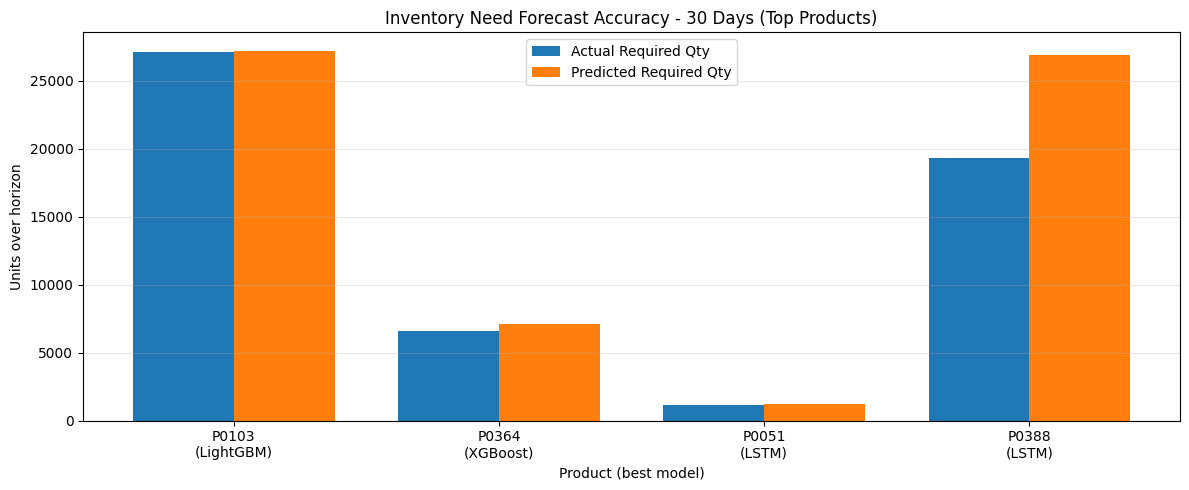

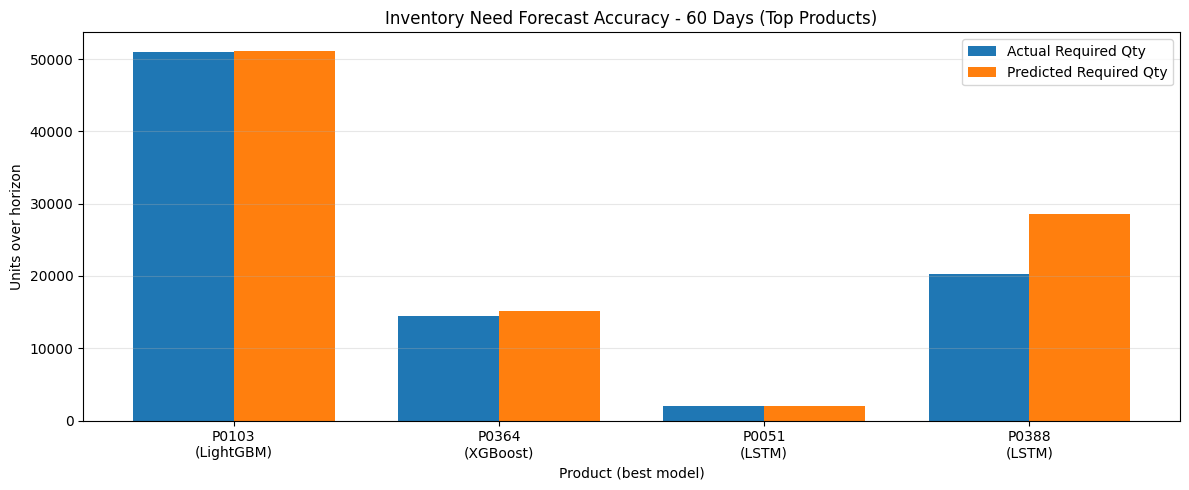

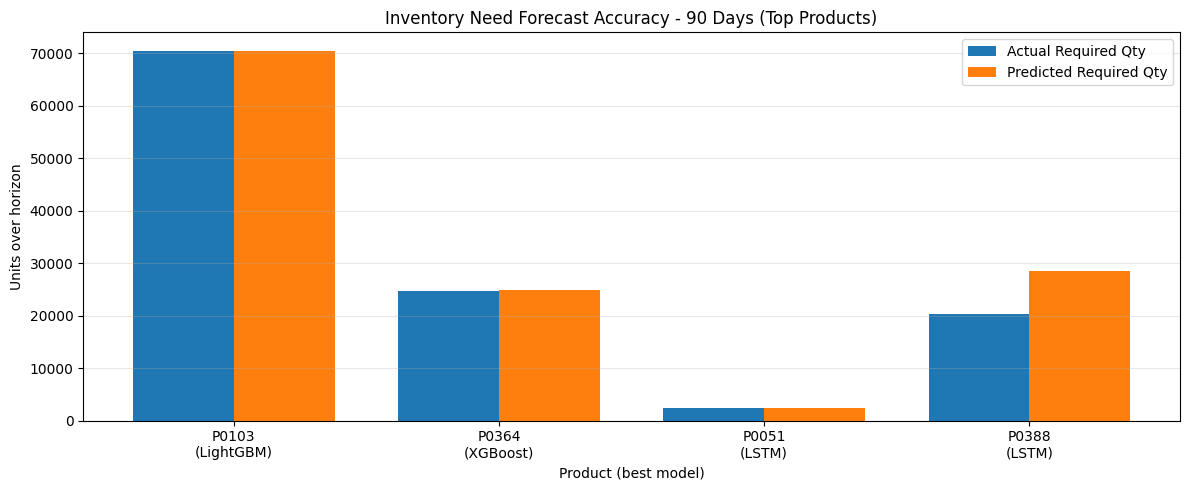

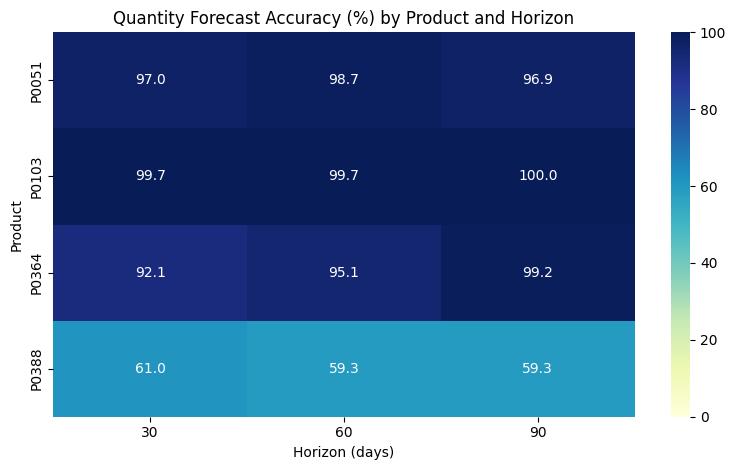

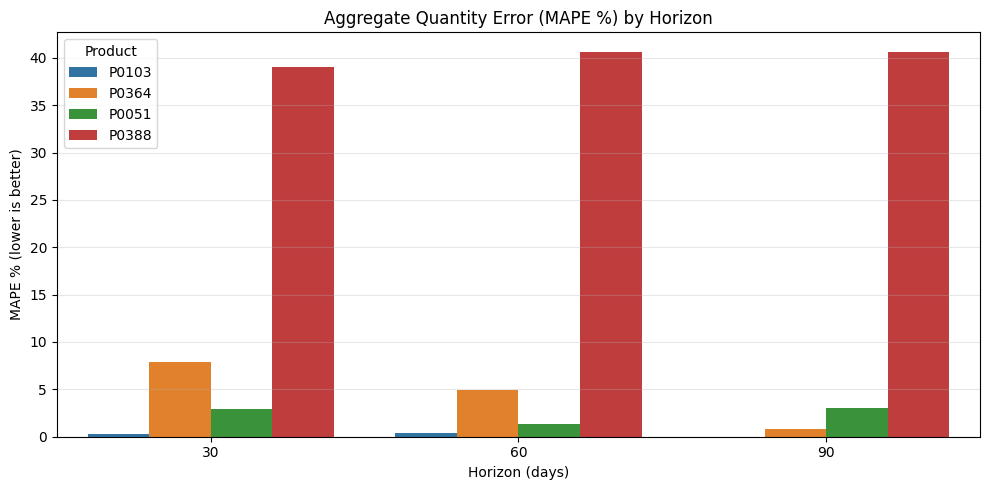

In [22]:
# Best-model horizon accuracy and inventory requirement view for top-selling products
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1) Candidate top sellers from strict pool, then keep only products that were actually trained
top5_candidates = (
    df[df['product_id'].isin(strict_products)]
      .groupby('product_id')['sales']
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .index
    .tolist()
)

trained_products = sorted(
    set(lgbm_results.keys())
    & set(xgb_results.keys())
    & set(lstm_results.keys())
)

top5_trained = [p for p in top5_candidates if p in trained_products]
if len(top5_trained) < 5:
    print(f"Warning: only {len(top5_trained)} of top-5 strict products are available after training filters.")
    print(f"Using products: {top5_trained}")

# 2) Pick best model per product using RMSE from comparison_df
best_rows = []
for product in top5_trained:
    row = comparison_df[comparison_df['Product'] == product].sort_values('RMSE').iloc[0]
    best_rows.append(row)
best_model_df = pd.DataFrame(best_rows).reset_index(drop=True)
print('Best model per product:')
display(best_model_df[['Product', 'Model', 'RMSE', 'MAE', 'R2']])

model_results_lookup = {
    'LightGBM': lgbm_results,
    'XGBoost': xgb_results,
    'LSTM': lstm_results,
}

# 3) Horizon metrics for 30/60/90 days
horizons = [30, 60, 90]
rows = []

for _, r in best_model_df.iterrows():
    product = r['Product']
    model_name = r['Model']
    result = model_results_lookup[model_name][product]

    y_true_full = np.asarray(result['y_test']).astype(float).ravel()
    y_pred_full = np.asarray(result['preds']).astype(float).ravel()

    for h in horizons:
        n = min(h, len(y_true_full), len(y_pred_full))
        if n < 5:
            continue

        y_true = y_true_full[:n]
        y_pred = y_pred_full[:n]

        rmse_h = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae_h = float(mean_absolute_error(y_true, y_pred))

        # Inventory-oriented quantity accuracy (aggregate demand over horizon)
        qty_actual = float(y_true.sum())
        qty_pred = float(y_pred.sum())
        qty_abs_err = abs(qty_pred - qty_actual)
        qty_mape = (qty_abs_err / qty_actual * 100.0) if qty_actual > 0 else np.nan
        qty_accuracy = (1.0 - qty_abs_err / qty_actual) * 100.0 if qty_actual > 0 else np.nan

        rows.append({
            'Product': product,
            'BestModel': model_name,
            'HorizonDays': n,
            'RMSE': rmse_h,
            'MAE': mae_h,
            'QtyActual': qty_actual,
            'QtyPredicted': qty_pred,
            'QtyAbsError': qty_abs_err,
            'QtyMAPE_pct': qty_mape,
            'QtyAccuracy_pct': qty_accuracy,
        })

top5_horizon_df = pd.DataFrame(rows)
print('\nTop-5 horizon forecast and inventory accuracy:')
display(top5_horizon_df.sort_values(['HorizonDays', 'Product']).reset_index(drop=True))

# 4) Visualization A: required quantity (actual vs predicted) for 30/60/90
for h in horizons:
    d = top5_horizon_df[top5_horizon_df['HorizonDays'] == h].copy()
    if d.empty:
        continue

    x = np.arange(len(d))
    w = 0.38

    plt.figure(figsize=(12, 5))
    plt.bar(x - w / 2, d['QtyActual'], width=w, label='Actual Required Qty')
    plt.bar(x + w / 2, d['QtyPredicted'], width=w, label='Predicted Required Qty')
    plt.xticks(x, [f"{p}\n({m})" for p, m in zip(d['Product'], d['BestModel'])], rotation=0)
    plt.ylabel('Units over horizon')
    plt.xlabel('Product (best model)')
    plt.title(f'Inventory Need Forecast Accuracy - {h} Days (Top Products)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 5) Visualization B: quantity accuracy heatmap (product x horizon)
if not top5_horizon_df.empty:
    heat = top5_horizon_df.pivot(index='Product', columns='HorizonDays', values='QtyAccuracy_pct')
    plt.figure(figsize=(8, 4.8))
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlGnBu', vmin=0, vmax=100)
    plt.title('Quantity Forecast Accuracy (%) by Product and Horizon')
    plt.xlabel('Horizon (days)')
    plt.ylabel('Product')
    plt.tight_layout()
    plt.show()

# 6) Visualization C: horizon-wise error bars
if not top5_horizon_df.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=top5_horizon_df, x='HorizonDays', y='QtyMAPE_pct', hue='Product')
    plt.title('Aggregate Quantity Error (MAPE %) by Horizon')
    plt.xlabel('Horizon (days)')
    plt.ylabel('MAPE % (lower is better)')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()